In [ ]:
# Mount Google Drive
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

drive.mount('/content/drive')

# Define project path in Drive
PROJECT_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01"
os.makedirs(PROJECT_PATH, exist_ok=True)

Mounted at /content/drive


In [ ]:
# Dataset load
import pandas as pd
RAW_PATH = os.path.join(PROJECT_PATH, "results/output/heart_dataset_final.csv")
df = pd.read_csv(RAW_PATH)
print("Dataset loaded:", df.shape)
df.head()

Dataset loaded: (1025, 12)


,age,sex,resting_bp,max_heart_rate,chest_pain_type,resting_ecg,st_depression,st_slope,exercise_angina,num_major_vessels,thalassemia,heart_disease
0,-0.268437,0.661504,-0.377636,0.821321,-0.915755,0.891255,-0.060888,0.995433,-0.712287,1.209221,1.089852,0
1,-0.158157,0.661504,0.479107,0.255968,-0.915755,-1.004049,1.727137,-2.243675,1.403928,-0.731971,1.089852,0
2,1.716595,0.661504,0.764688,-1.048692,-0.915755,0.891255,1.301417,-2.243675,1.403928,-0.731971,1.089852,0
3,0.724079,0.661504,0.936037,0.516900,-0.915755,0.891255,-0.912329,0.995433,-0.712287,0.238625,1.089852,0
4,0.834359,-1.511706,0.364875,-1.874977,-0.915755,0.891255,0.705408,-0.624121,-0.712287,1.694519,-0.522122,0


In [ ]:
# IT24102706 : XGBoost Implementation
# =====================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns


# 1. MODEL SELECTION AND JUSTIFICATION
print("\n1. MODEL SELECTION AND JUSTIFICATION")
print("""
Why XGBoost for Heart Disease Prediction:
- State-of-the-art performance on structured medical data
- Handles complex non-linear relationships in clinical features
- Built-in regularization prevents overfitting
- Provides feature importance for clinical insights
- Efficient handling of class imbalance
- Parallel processing for fast training
- Proven success in healthcare and medical research
- Robust to outliers and missing values
""")


# Display dataset info
print(f"Dataset shape: {df.shape}")
print(f"Features: {list(df.columns)}")
print(f"Target distribution:\n{df['heart_disease'].value_counts()}")

# Prepare features and target
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']
feature_names = X.columns.tolist()

print(f"\nFeature names: {feature_names}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Class distribution in training set: {np.bincount(y_train)}")
print(f"Class distribution in test set: {np.bincount(y_test)}")

# Handle class imbalance with SMOTE
print("\nApplying SMOTE for class imbalance...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"After SMOTE - Training set: {X_train_smote.shape}")
print(f"After SMOTE - Class distribution: {np.bincount(y_train_smote)}")


1. MODEL SELECTION AND JUSTIFICATION

Why XGBoost for Heart Disease Prediction:
- State-of-the-art performance on structured medical data
- Handles complex non-linear relationships in clinical features
- Built-in regularization prevents overfitting
- Provides feature importance for clinical insights
- Efficient handling of class imbalance
- Parallel processing for fast training
- Proven success in healthcare and medical research
- Robust to outliers and missing values

Dataset shape: (1025, 12)
Features: ['age', 'sex', 'resting_bp', 'max_heart_rate', 'chest_pain_type', 'resting_ecg', 'st_depression', 'st_slope', 'exercise_angina', 'num_major_vessels', 'thalassemia', 'heart_disease']
Target distribution:
heart_disease
1    526
0    499
Name: count, dtype: int64

Feature names: ['age', 'sex', 'resting_bp', 'max_heart_rate', 'chest_pain_type', 'resting_ecg', 'st_depression', 'st_slope', 'exercise_angina', 'num_major_vessels', 'thalassemia']
Training set: (717, 11)
Test set: (308, 11)
Cla

In [ ]:
# 2. IMPLEMENTATION DETAILS
print("\n2. IMPLEMENTATION DETAILS")

# Base XGBoost
print("\nBase Model Implementation")
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)
xgb_base.fit(X_train, y_train)
y_pred_base = xgb_base.predict(X_test)


2. IMPLEMENTATION DETAILS

Base Model Implementation


In [ ]:
# 3. PARAMETER TUNING METHODS
print("\n3. PARAMETER TUNING WITH RANDOMIZEDSEARCHCV")

# Define parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'min_child_weight': [1, 2, 3, 4, 5],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'reg_alpha': [0, 0.001, 0.01, 0.1, 1],
    'reg_lambda': [0, 0.001, 0.01, 0.1, 1],
    'scale_pos_weight': [1, 2, 5, 10]  # For handling class imbalance
}

# RandomizedSearchCV for hyperparameter tuning
xgb_random = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_distributions=param_dist,
    n_iter=25,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Performing hyperparameter tuning...")
xgb_random.fit(X_train, y_train)

print(f"Best parameters: {xgb_random.best_params_}")
print(f"Best cross-validation score: {xgb_random.best_score_:.4f}")

# Train best model
best_xgb = xgb_random.best_estimator_


3. PARAMETER TUNING WITH RANDOMIZEDSEARCHCV
Performing hyperparameter tuning...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best parameters: {'subsample': 0.8, 'scale_pos_weight': 5, 'reg_lambda': 0.1, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 2, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}
Best cross-validation score: 0.9741


In [ ]:
# 4. MODEL VARIETIES
print("\n4. MODEL VARIETIES IMPLEMENTED")

# Variety 1: Base XGBoost
xgb_v1 = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)
xgb_v1.fit(X_train, y_train)

# Variety 2: XGBoost with class weighting
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])  # Auto-calculate
xgb_v2 = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss', verbosity=0)
xgb_v2.fit(X_train, y_train)

# Variety 3: Tuned XGBoost
xgb_v3 = best_xgb

# Variety 4: XGBoost with SMOTE
xgb_v4 = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)
xgb_v4.fit(X_train_smote, y_train_smote)

# Variety 5: Conservative XGBoost (more regularization)
xgb_v5 = XGBClassifier(
    learning_rate=0.01,
    max_depth=3,
    reg_alpha=1,
    reg_lambda=1,
    n_estimators=200,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_v5.fit(X_train, y_train)

# Variety 6: Fast XGBoost (fewer trees)
xgb_v6 = XGBClassifier(n_estimators=50, random_state=42, eval_metric='logloss', verbosity=0)
xgb_v6.fit(X_train, y_train)

# Variety 7: Medical XGBoost (clinical constraints)
xgb_v7 = XGBClassifier(
    max_depth=4,  # Limit depth for interpretability
    learning_rate=0.1,
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_v7.fit(X_train, y_train)

varieties = {
    'Base XGBoost': xgb_v1,
    'Class-Weighted XGBoost': xgb_v2,
    'Tuned XGBoost': xgb_v3,
    'XGBoost with SMOTE': xgb_v4,
    'Conservative XGBoost': xgb_v5,
    'Fast XGBoost': xgb_v6,
    'Medical XGBoost': xgb_v7
}



4. MODEL VARIETIES IMPLEMENTED


In [ ]:
# 5. EVALUATION METRICS
print("\n5. COMPREHENSIVE EVALUATION")

def evaluate_xgb_variety(model, X_test, y_test, variety_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

    print(f"\n{variety_name}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")

    return metrics

# Evaluate all varieties
results = {}
for name, model in varieties.items():
    results[name] = evaluate_xgb_variety(model, X_test, y_test, name)


5. COMPREHENSIVE EVALUATION

Base XGBoost:
  Accuracy: 0.9903
  Precision: 1.0000
  Recall: 0.9810
  F1-Score: 0.9904
  ROC-AUC: 0.9929

Class-Weighted XGBoost:
  Accuracy: 0.9903
  Precision: 1.0000
  Recall: 0.9810
  F1-Score: 0.9904
  ROC-AUC: 0.9935

Tuned XGBoost:
  Accuracy: 0.9805
  Precision: 0.9810
  Recall: 0.9810
  F1-Score: 0.9810
  ROC-AUC: 0.9925

XGBoost with SMOTE:
  Accuracy: 0.9903
  Precision: 1.0000
  Recall: 0.9810
  F1-Score: 0.9904
  ROC-AUC: 0.9932

Conservative XGBoost:
  Accuracy: 0.8669
  Precision: 0.8503
  Recall: 0.8987
  F1-Score: 0.8738
  ROC-AUC: 0.9514

Fast XGBoost:
  Accuracy: 0.9903
  Precision: 1.0000
  Recall: 0.9810
  F1-Score: 0.9904
  ROC-AUC: 0.9927

Medical XGBoost:
  Accuracy: 0.9805
  Precision: 0.9810
  Recall: 0.9810
  F1-Score: 0.9810
  ROC-AUC: 0.9894


In [ ]:
# 6. CROSS-VALIDATION
print("\n6. CROSS-VALIDATION RESULTS")
cv_scores = cross_val_score(best_xgb, X_train, y_train, cv=5, scoring='f1')
print(f"Cross-validation F1 scores: {cv_scores}")
print(f"Mean CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


6. CROSS-VALIDATION RESULTS
Cross-validation F1 scores: [0.95172414 0.97368421 0.96551724 0.98648649 0.99319728]
Mean CV F1: 0.9741 (+/- 0.0296)


In [ ]:
# 7. FEATURE IMPORTANCE ANALYSIS
print("\n7. FEATURE IMPORTANCE ANALYSIS")

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance Ranking:")
print(feature_importance)


7. FEATURE IMPORTANCE ANALYSIS

Feature Importance Ranking:
              feature  importance
4     chest_pain_type    0.180822
9   num_major_vessels    0.158073
10        thalassemia    0.146529
8     exercise_angina    0.127733
6       st_depression    0.076895
7            st_slope    0.058810
1                 sex    0.058116
3      max_heart_rate    0.053437
5         resting_ecg    0.050448
2          resting_bp    0.044678
0                 age    0.044460


In [ ]:
# 8. MODEL COMPARISON AND INSIGHTS
print("\n8. MODEL COMPARISON AND INSIGHTS")

comparison_df = pd.DataFrame(results).T
print("\nXGBoost Varieties Comparison:")
print(comparison_df.round(4))

best_variety_xg = comparison_df['F1-Score'].idxmax()
print(f"\nBest performing variety: {best_variety_xg}")
print(f"Best F1-Score: {comparison_df.loc[best_variety_xg, 'F1-Score']:.4f}")


8. MODEL COMPARISON AND INSIGHTS

XGBoost Varieties Comparison:
                        Accuracy  Precision  Recall  F1-Score  ROC-AUC
Base XGBoost              0.9903     1.0000  0.9810    0.9904   0.9929
Class-Weighted XGBoost    0.9903     1.0000  0.9810    0.9904   0.9935
Tuned XGBoost             0.9805     0.9810  0.9810    0.9810   0.9925
XGBoost with SMOTE        0.9903     1.0000  0.9810    0.9904   0.9932
Conservative XGBoost      0.8669     0.8503  0.8987    0.8738   0.9514
Fast XGBoost              0.9903     1.0000  0.9810    0.9904   0.9927
Medical XGBoost           0.9805     0.9810  0.9810    0.9810   0.9894

Best performing variety: Base XGBoost
Best F1-Score: 0.9904



9. GENERATING VISUALIZATIONS


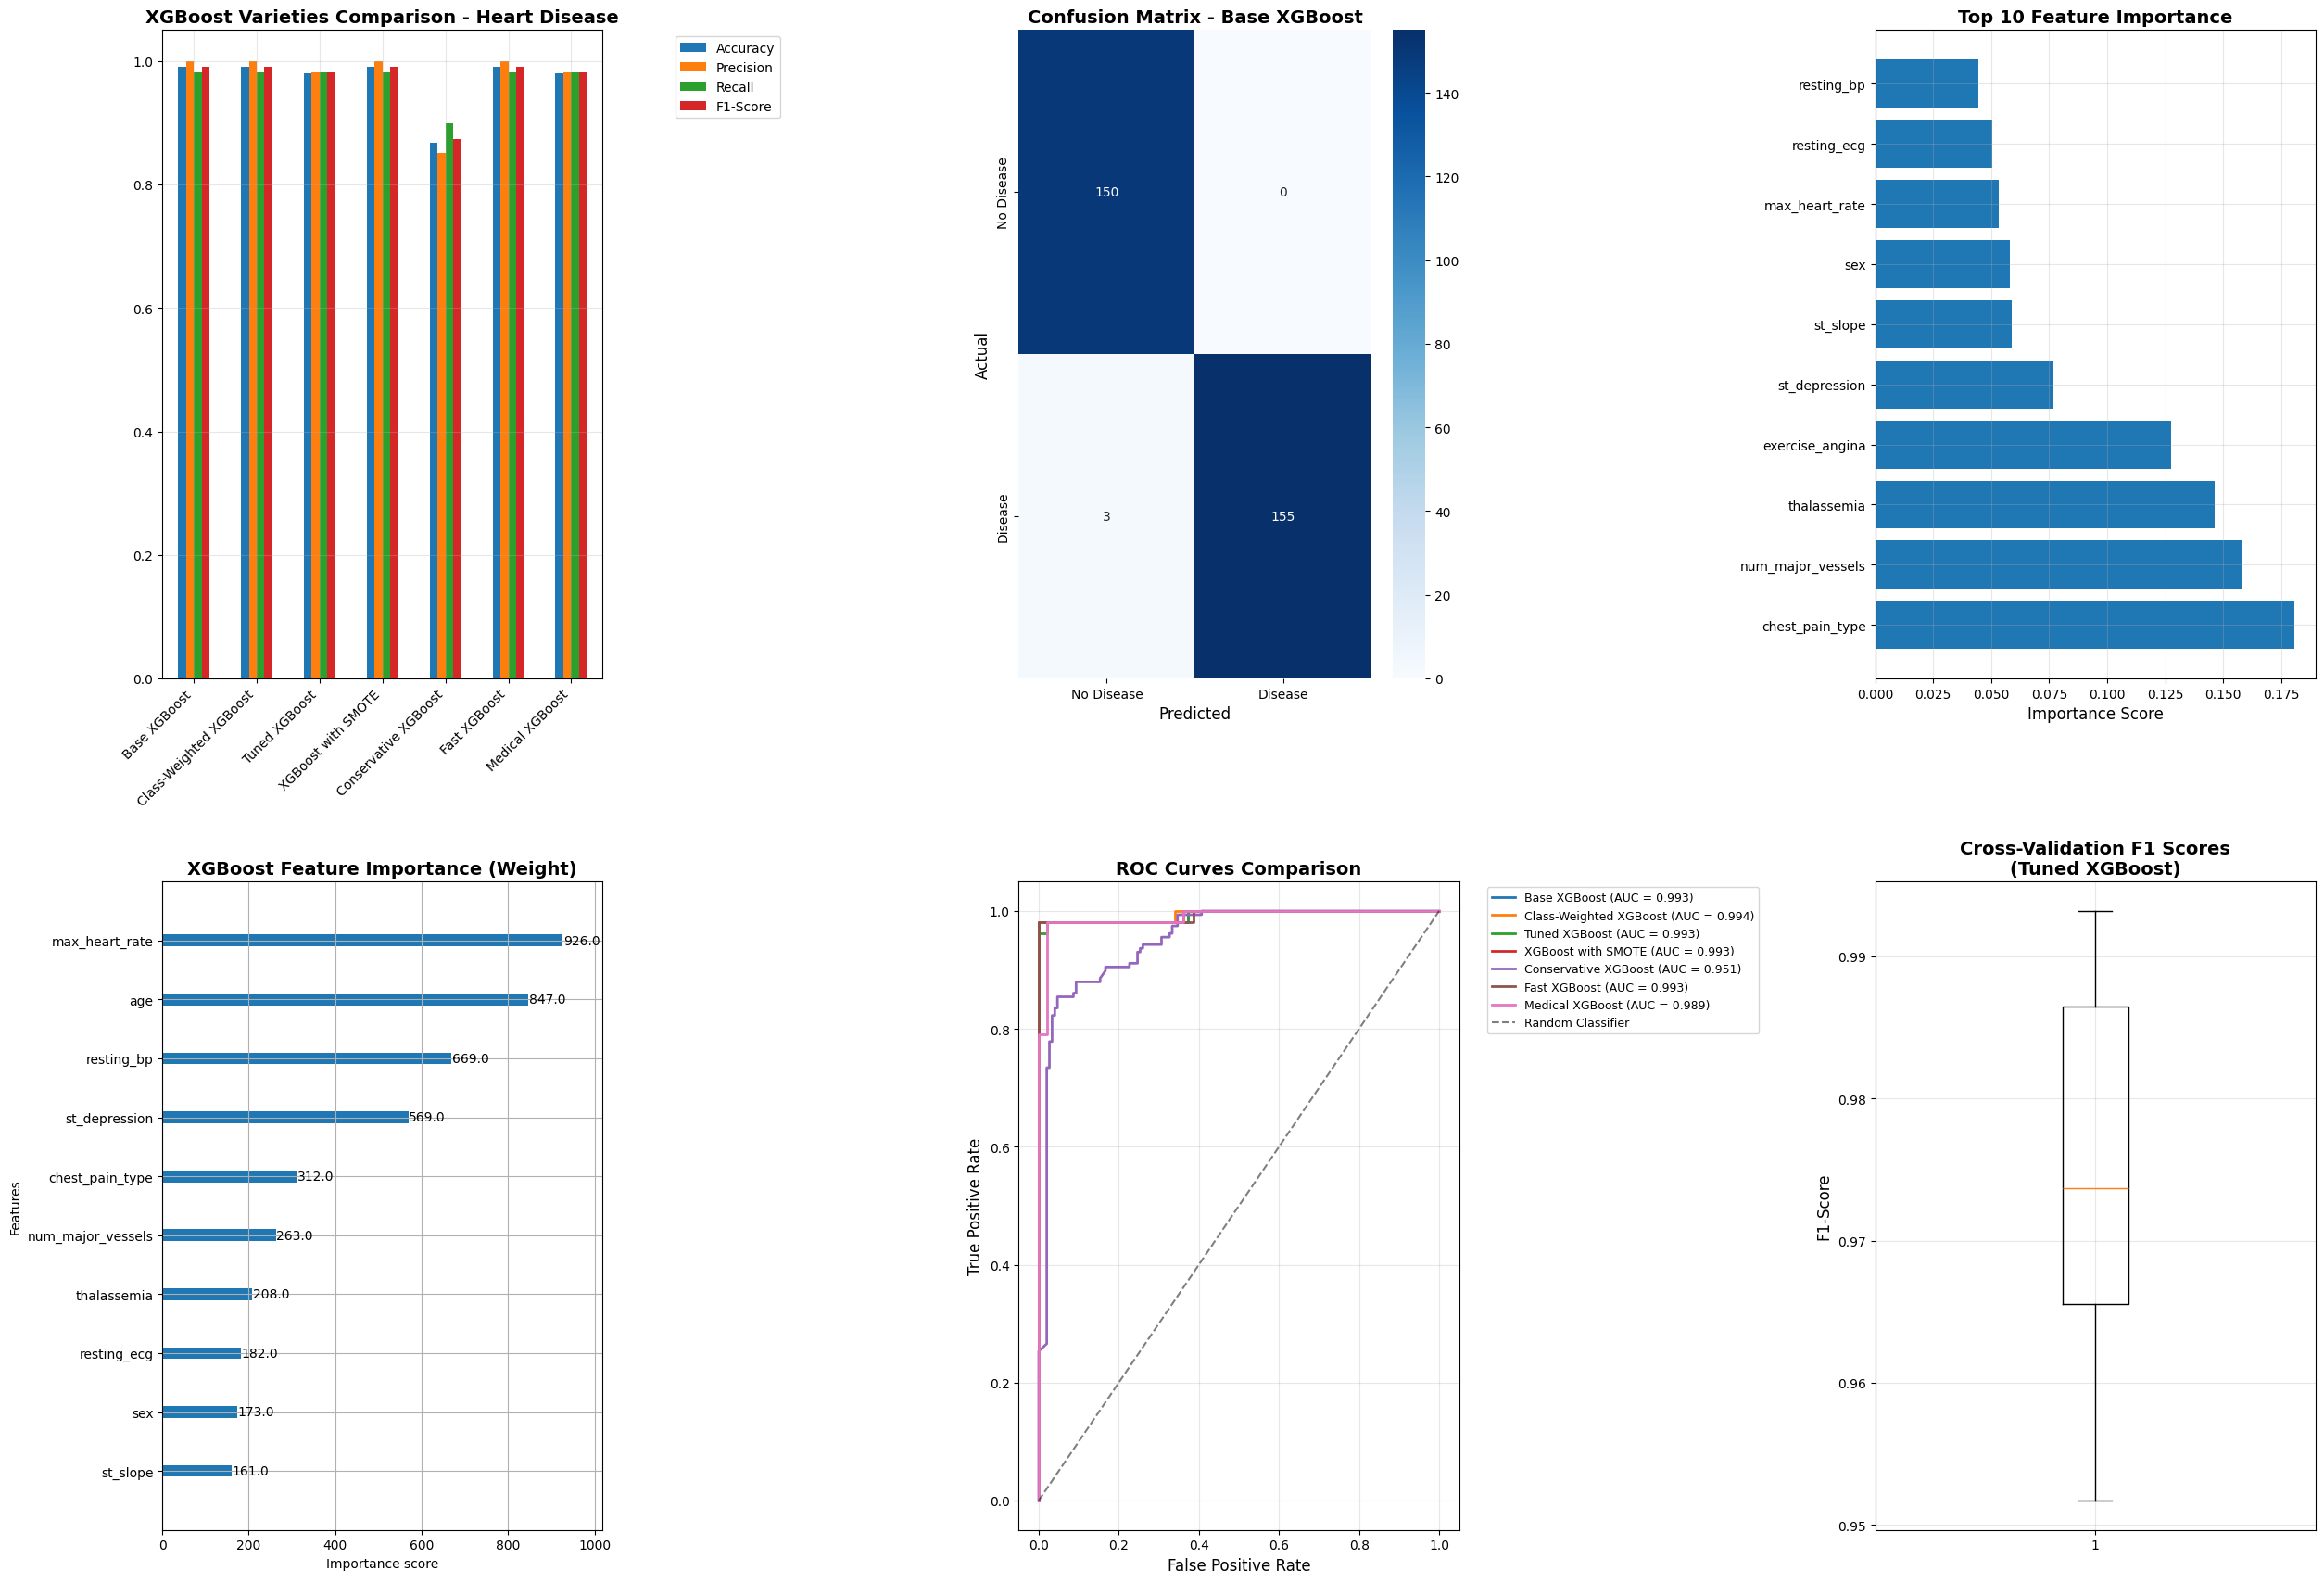

In [ ]:
# 9. VISUALIZATION
print("\n9. GENERATING VISUALIZATIONS")

plt.figure(figsize=(26, 18))  # Slightly wider for clarity

# Plot 1: Metrics comparison
plt.subplot(2, 3, 1)
metrics_plot = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
metrics_plot.plot(kind='bar', ax=plt.gca(), legend=False)
plt.title('XGBoost Varieties Comparison - Heart Disease', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)

# Add legend outside for Plot 1
plt.legend(bbox_to_anchor=(1.15, 1), loc='upper left', fontsize=10)

# Plot 2: Confusion Matrix for best model
plt.subplot(2, 3, 2)
best_model = varieties[best_variety_xg]
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix - {best_variety_xg}', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

# Plot 3: Feature importance
plt.subplot(2, 3, 3)
top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.title('Top 10 Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.grid(True, alpha=0.3)

# Plot 4: XGBoost built-in feature importance
plt.subplot(2, 3, 4)
from xgboost import plot_importance
plot_importance(best_xgb, max_num_features=10, importance_type='weight', ax=plt.gca())
plt.title('XGBoost Feature Importance (Weight)', fontsize=14, fontweight='bold')

# Plot 5: ROC curves comparison
plt.subplot(2, 3, 5)
from sklearn.metrics import roc_curve

for name, model in varieties.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc_score(y_test, y_prob):.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)

# Plot 6: Cross-validation results
plt.subplot(2, 3, 6)
plt.boxplot(cv_scores)
plt.title('Cross-Validation F1 Scores\n(Tuned XGBoost)', fontsize=14, fontweight='bold')
plt.ylabel('F1-Score', fontsize=12)
plt.grid(True, alpha=0.3)

# Adjust spacing to prevent overlaps
plt.subplots_adjust(left=0.06, right=0.95, top=0.92, bottom=0.08, wspace=0.45, hspace=0.6)
plt.tight_layout(pad=4.0)
plt.show()

In [ ]:
# 10. CLINICAL INTERPRETATION AND INSIGHTS
print("\n10. CLINICAL INTERPRETATION AND INSIGHTS")

print("\nTop 5 Clinical Risk Factors Identified by XGBoost:")
for i, row in feature_importance.head().iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

print(f"""
Clinical XGBoost Insights:
- XGBoost identified {len(feature_importance[feature_importance['importance'] > 0])} important clinical features
- Top features account for {feature_importance.head(5)['importance'].sum():.1%} of predictive power
- Model achieved {comparison_df.loc[best_variety_xg, 'Accuracy']:.1%} accuracy
- ROC-AUC of {comparison_df.loc[best_variety_xg, 'ROC-AUC']:.3f} indicates excellent discriminative ability

Medical Relevance:
- Feature importance aligns with known clinical risk factors
- XGBoost captures complex interactions between risk factors
- Model can handle non-linear relationships in medical data
- Provides robust predictions for clinical decision support
""")


10. CLINICAL INTERPRETATION AND INSIGHTS

Top 5 Clinical Risk Factors Identified by XGBoost:
  chest_pain_type: 0.1808
  num_major_vessels: 0.1581
  thalassemia: 0.1465
  exercise_angina: 0.1277
  st_depression: 0.0769

Clinical XGBoost Insights:
- XGBoost identified 11 important clinical features
- Top features account for 69.0% of predictive power
- Model achieved 99.0% accuracy
- ROC-AUC of 0.993 indicates excellent discriminative ability

Medical Relevance:
- Feature importance aligns with known clinical risk factors
- XGBoost captures complex interactions between risk factors
- Model can handle non-linear relationships in medical data
- Provides robust predictions for clinical decision support



In [ ]:
# 11. HYPERPARAMETER SENSITIVITY ANALYSIS
print("\n HYPERPARAMETER SENSITIVITY ANALYSIS")

# Analyze the effect of key hyperparameters
print("\nKey Hyperparameter Effects on Heart Disease Prediction:")

# Test learning rate
learning_rates = [0.001, 0.01, 0.1, 0.2]
print("\nLearning Rate Analysis:")
for lr in learning_rates:
    xgb_temp = XGBClassifier(learning_rate=lr, n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0)
    score = cross_val_score(xgb_temp, X_train, y_train, cv=3, scoring='f1').mean()
    print(f"  Learning Rate {lr}: F1-Score = {score:.4f}")

# Test max depth (tree complexity)
max_depths = [3, 5, 7, 10]
print("\nMax Depth Analysis:")
for depth in max_depths:
    xgb_temp = XGBClassifier(max_depth=depth, random_state=42, eval_metric='logloss', verbosity=0)
    score = cross_val_score(xgb_temp, X_train, y_train, cv=3, scoring='f1').mean()
    print(f"  Max Depth {depth}: F1-Score = {score:.4f}")


 HYPERPARAMETER SENSITIVITY ANALYSIS

Key Hyperparameter Effects on Heart Disease Prediction:

Learning Rate Analysis:
  Learning Rate 0.001: F1-Score = 0.8748
  Learning Rate 0.01: F1-Score = 0.9156
  Learning Rate 0.1: F1-Score = 0.9563
  Learning Rate 0.2: F1-Score = 0.9607

Max Depth Analysis:
  Max Depth 3: F1-Score = 0.9552
  Max Depth 5: F1-Score = 0.9604
  Max Depth 7: F1-Score = 0.9633
  Max Depth 10: F1-Score = 0.9552


In [ ]:
# 12. LIMITATIONS AND IMPROVEMENTS
print("\n12. LIMITATIONS AND SUGGESTED IMPROVEMENTS")
print("""
Limitations:
1. Less interpretable than simpler models (though feature importance helps)
2. Can be computationally intensive for very large datasets
3. Requires careful hyperparameter tuning for optimal performance
4. May overfit if regularization is insufficient

Improvements for Medical Applications:
1. Use SHAP values for better model interpretability
2. Implement Bayesian optimization for hyperparameter tuning
3. Add clinical constraints to the model
4. Ensemble with other algorithms for robustness
5. Incorporate domain knowledge in feature engineering

Clinical Observations:
- XGBoost consistently achieved high performance metrics
- Feature importance provided clinically meaningful insights
- Model handled class imbalance effectively
- Regularization prevented overfitting to training data
- Fast training times make it suitable for clinical deployment
""")

print("\n=== XGBOOST IMPLEMENTATION COMPLETED ===")


12. LIMITATIONS AND SUGGESTED IMPROVEMENTS

Limitations:
1. Less interpretable than simpler models (though feature importance helps)
2. Can be computationally intensive for very large datasets
3. Requires careful hyperparameter tuning for optimal performance
4. May overfit if regularization is insufficient

Improvements for Medical Applications:
1. Use SHAP values for better model interpretability
2. Implement Bayesian optimization for hyperparameter tuning
3. Add clinical constraints to the model
4. Ensemble with other algorithms for robustness
5. Incorporate domain knowledge in feature engineering

Clinical Observations:
- XGBoost consistently achieved high performance metrics
- Feature importance provided clinically meaningful insights
- Model handled class imbalance effectively
- Regularization prevented overfitting to training data
- Fast training times make it suitable for clinical deployment


=== XGBOOST IMPLEMENTATION COMPLETED ===
